# Decision Tree Worksheet

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

## YOUR CODE HERE
data = pd.read_csv(url, names=names)

# Dropping NaN rows
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)
data.head()

# Splitting data
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

/tmp/ipykernel_321/3442244639.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [ ]:
## YOUR CODE HERE

decision_tree=DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=5, min_samples_leaf=5)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
y_train_pred=decision_tree.predict(X_train)
print("AUC of training:", accuracy_score(y_train, y_train_pred) * 100)
y_val_pred=decision_tree.predict(X_val)
print("AUC of val:", accuracy_score(y_val, y_val_pred) * 100)

AUC of training: 84.8
AUC of val: 77.77777777777779


Make a model with a low max-depth and higher minimum sample leafs.

In [ ]:
## YOUR CODE HERE

decision_tree_2=DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=2, min_samples_leaf=10)
decision_tree_2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=10)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
y_train_pred=decision_tree_2.predict(X_train)
print("AUC of training:", accuracy_score(y_train, y_train_pred) * 100)
y_val_pred=decision_tree_2.predict(X_val)
print("AUC of val:", accuracy_score(y_val, y_val_pred) * 100)

AUC of training: 80.80000000000001
AUC of val: 77.77777777777779


Explain the accuracy results below.

(YOUR ANSWER HERE)
High Max Depth and Low Minimum Sample Leaves led to higher accuracy on training data than Low Max Depth and Higher Minimum Sample Leaves. However, accuracy on validation was unchanged.

## Metrics

Plot the ROC curve and print the AUC of the second model.

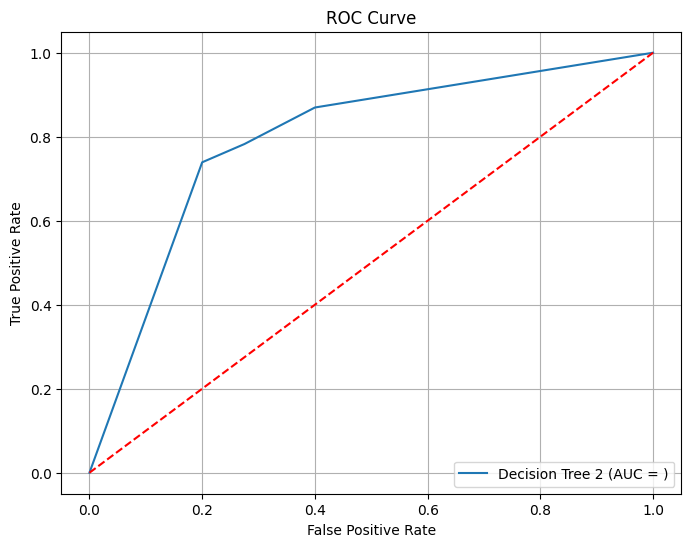

AUC of the second model on validation data: 0.7951086956521739


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = decision_tree_2.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Decision Tree 2 (AUC = )' % roc_auc_score(y_val, y_pred_proba))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"AUC of the second model on validation data: {auc_score:}")

Use graphviz to visualize your 2nd tree.

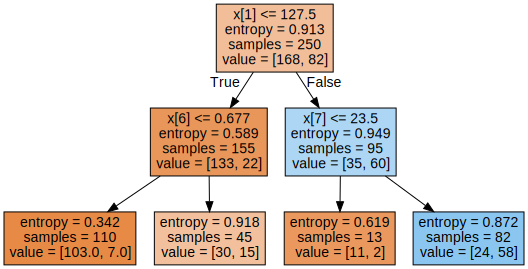

In [ ]:
## YOUR CODE HERE

dot_data = tree.export_graphviz(decision_tree_2, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents
in the nodes from the graph?

(YOUR ANSWER HERE)

it refers to a specific feature (since it is different columns)

Question 2: What is the root feature? Does it make sense as the root feature?

(YOUR ANSWER HERE)

It is plas (plasma glucose concentration). This makes sense for diabetes prediction and is likely one of the most determinative/predictive factors

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

(YOUR ANSWER HERE)

I think it would overfit since the 500 depth would lead to it being near perfect on training. but in real practice with the val data it would do poorly bc of the overfitting

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [ ]:
## YOUR CODE HERE

## YOUR CODE HERE

decision_tree_3=DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth=500, min_samples_leaf=1)
decision_tree_3.fit(X_train, y_train)

y_train_pred=decision_tree_3.predict(X_train)
print("AUC of training:", accuracy_score(y_train, y_train_pred) * 100)
y_val_pred=decision_tree_3.predict(X_val)
print("AUC of val:", accuracy_score(y_val, y_val_pred) * 100)

AUC of training: 100.0
AUC of val: 77.77777777777779


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [ ]:
## YOUR CODE HERE
random_forest = RandomForestClassifier(n_estimators=100)

random_forest.fit(X_train, y_train)

RandomForestClassifier()

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE

y_train_pred=random_forest.predict(X_train)
print("AUC of training:", accuracy_score(y_train, y_train_pred) * 100)
y_val_pred=random_forest.predict(X_val)
print("AUC of val:", accuracy_score(y_val, y_val_pred) * 100)

AUC of training: 100.0
AUC of val: 79.36507936507937


How did the accuracy compare to the decision tree's accuracy?

(YOUR ANSWER HERE)

slight improvement in val accuracy. training remains same - 100%

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [ ]:
## YOUR CODE HERE

importances = random_forest.feature_importances_
feature_names = X_train.columns

# pandas instantiation
feature_importances = pd.Series(importances, index=feature_names)

# descended
sorted_features = feature_importances.sort_values(ascending=False)

print("3 most important features:")
print(sorted_features.head(3))

3 most important features:
plas    0.243606
test    0.160492
age     0.127483
dtype: float64


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

N_Estimators: 96, Validation Accuracy: 73.02%
N_Estimators: 96, Validation Accuracy: 71.43%
N_Estimators: 96, Validation Accuracy: 80.95%
N_Estimators: 96, Validation Accuracy: 77.78%
N_Estimators: 96, Validation Accuracy: 79.37%
N_Estimators: 96, Validation Accuracy: 84.13%
N_Estimators: 96, Validation Accuracy: 84.13%
N_Estimators: 96, Validation Accuracy: 84.13%
N_Estimators: 96, Validation Accuracy: 84.13%
N_Estimators: 96, Validation Accuracy: 82.54%
N_Estimators: 96, Validation Accuracy: 84.13%
N_Estimators: 96, Validation Accuracy: 82.54%
N_Estimators: 96, Validation Accuracy: 85.71%
N_Estimators: 96, Validation Accuracy: 82.54%
N_Estimators: 96, Validation Accuracy: 80.95%
N_Estimators: 96, Validation Accuracy: 85.71%
N_Estimators: 96, Validation Accuracy: 85.71%
N_Estimators: 96, Validation Accuracy: 80.95%
N_Estimators: 96, Validation Accuracy: 79.37%
N_Estimators: 96, Validation Accuracy: 77.78%


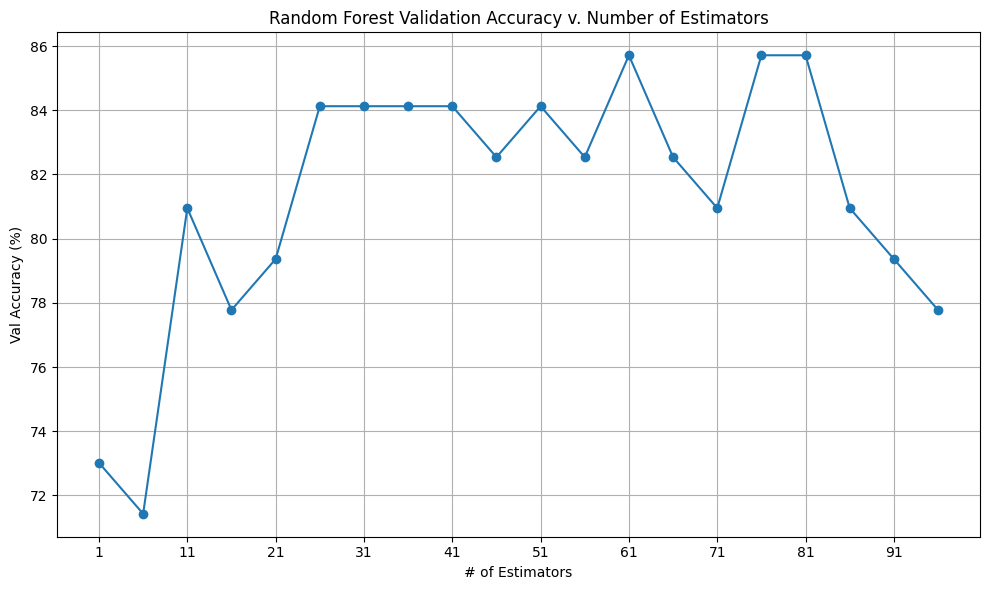

In [ ]:
## YOUR CODE HERE

estimators = range(1, 101, 5)
accuracies = []

for i in estimators:
    random_forest = RandomForestClassifier(n_estimators=i, random_state=42)
    random_forest.fit(X_train, y_train)
    y_val_pred = random_forest.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred) * 100
    accuracies.append(acc)
    print(f"N_Estimators: {n_est}, Validation Accuracy: {acc:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(estimators, accuracies, marker='o', linestyle='-')
plt.title('Random Forest Validation Accuracy v. Number of Estimators')
plt.xlabel('# of Estimators')
plt.ylabel('Val Accuracy (%)')
plt.grid(True)
plt.xticks(list(estimators[::2])) # Show fewer x-ticks for better readability
plt.tight_layout()
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

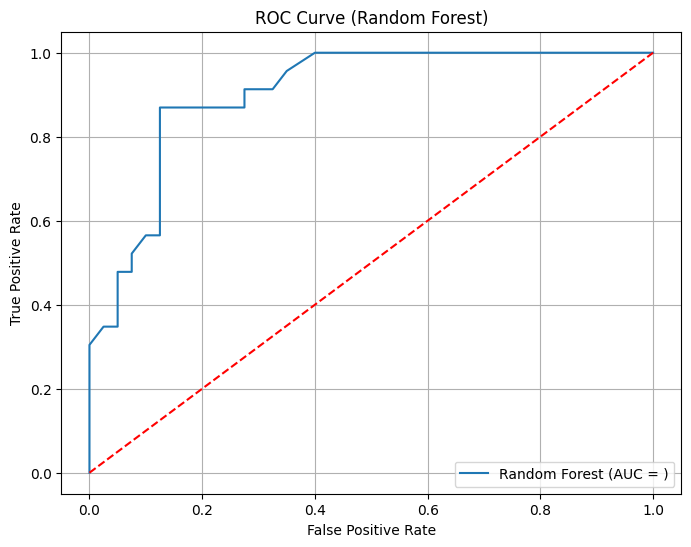

AUC of the Random Forest model (val): 0.90


In [ ]:
## YOUR CODE HERE
from sklearn.metrics import roc_curve, roc_auc_score
#rf = random_forest (too long to type out)
y_pred_proba_rf = random_forest.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_val, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = )' % roc_auc_score(y_val, y_pred_proba_rf))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

auc_score_rf = roc_auc_score(y_val, y_pred_proba_rf)
print(f"AUC of the Random Forest model (val): {auc_score_rf:.2f}")